In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import math
from sklearn.preprocessing import StandardScaler
import shap

# Data Preparation

## Data Loading and Splitting

In [2]:
# Load Data
# Create 2 copies to retain the original
df = pd.read_csv('postproc_comp.csv')
df_all = pd.read_csv('postproc_comp.csv')

In [3]:
# Drop index and district names (row identifiers)
df = df.drop(['Unnamed: 0', 'State_District_Name'], axis=1)

In [4]:
df.head(5)

,State_Name,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,AA_Population_Urban,...,ZZ_Crude_Death_Rate_Rural_Lower_Limit,ZZ_Crude_Death_Rate_Rural_Upper_Limit,ZZ_Crude_Death_Rate_Urban_Lower_Limit,ZZ_Crude_Death_Rate_Urban_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Total_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
0,Assam,53,47,6,13711,12765,946,64606,60293,4313,...,5.9,7.5,4.1,8.2,871,985,851,965,908.0,1611.0
1,Assam,89,73,16,17384,14904,2480,84012,73899,10113,...,5.7,6.9,3.9,6.2,897,1005,911,1026,621.0,956.0
2,Assam,105,84,21,27488,24207,3281,127158,112171,14987,...,6.9,8.0,5.7,7.4,891,966,871,949,905.0,1168.0
3,Assam,26,24,2,5951,5769,182,29048,28256,792,...,6.9,9.3,5.6,8.2,913,1102,908,1097,793.0,1091.0
4,Assam,121,108,13,14481,12619,1862,75451,66537,8914,...,4.1,4.9,3.6,4.9,935,1045,938,1054,772.0,1083.0


In [5]:
# Define target
target = 'YY_Infant_Mortality_Rate_Imr_Total_Person'
# Define X and y
# Create a dataframe and a series of y (Infant Mortality Rate)
X = df.drop(target, axis=1)
y = df[target]
y_df = df[[target]]

# 70/30 train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y_df,test_size=0.3,random_state=42)

## Encoding
- Target encoding the state name to avoid increasing dimensionality with One-Hot

In [6]:
from sklearn.preprocessing import TargetEncoder

In [7]:
# Continuous target encoder with cross-validation
encoder = TargetEncoder(target_type='continuous', cv=5)

In [8]:
# Target encode the state name to prevent dimensionality increase
X_train[['State_Name']] = encoder.fit_transform(X_train[['State_Name']], y_train)
X_test[['State_Name']] = encoder.transform(X_test[['State_Name']])

/home/lmn4121/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
X_train.head(5)

,State_Name,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,AA_Population_Urban,...,ZZ_Crude_Death_Rate_Rural_Lower_Limit,ZZ_Crude_Death_Rate_Rural_Upper_Limit,ZZ_Crude_Death_Rate_Urban_Lower_Limit,ZZ_Crude_Death_Rate_Urban_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Total_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
182,55.897076,64,57,7,16102,15134,968,79867,75246,4621,...,6.30,7.00,4.40,6.40,856,945,846,937,834.0,1392.0
55,48.299819,41,38,3,14986,14537,449,71690,69401,2289,...,7.00,8.00,6.30,6.70,883,975,873,966,846.0,1456.0
112,63.196396,99,33,66,17703,6046,11657,77369,25918,51451,...,5.30,6.70,5.00,6.10,777,867,746,886,772.0,889.0
221,64.919211,45,34,11,9054,8078,976,52944,47323,5621,...,7.39,8.67,5.65,9.12,865,975,875,992,668.0,1017.0
38,47.778355,38,32,6,12616,11633,983,61807,57103,4704,...,5.90,7.10,3.60,6.10,916,1021,925,1034,687.0,1078.0


## Outlier Handling / Scaling

In [10]:
# Upper and Lower limits for winsorizing target var
lower = y_train[target].quantile(0.05) 
upper = y_train[target].quantile(0.95)

# Apply winsorization to target var
#y_train[[target]] = y_train[[target]].clip(lower, upper)
#y_test[[target]] = y_test[[target]].clip(lower, upper)

# Scrapped: ultimately made models worse

In [11]:
# Apply robust scaling to features
# Too many features to handle skewness individually
# Robust scaling is robust to outliers
from sklearn.preprocessing import RobustScaler, StandardScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Initial Feature Selection
- Want to use feature selection over feature reduction (PCA) to retain feature identities (names)
  - Feature selection suffers with high dimensionality due to multicollinearity
  - Instead of applying feature selection to the entire featureset, we can apply selection to subsets of features to avoid multicollinearity
  - From EDA, it was discovered that multicollinearity is most notable between classes with the same prefix identifier (AA, BB, etc.)
    - We can use this property to split the data into subgroups with minimal multicollinearity, that is, correlation between features.
- Strategy:
  - Split the featureset into subgroups such that features with the same prefix identifiers are spread out from one another
  - Since the features are organized by prefix in alphabetical order, iteratively add each feature to a different subgroup
  - Apply feature selection to each subgroup and aggregate the results

## Split the features

In [12]:
import string

In [13]:
# Overview of corr between features
df.select_dtypes(include='number').corr().head(5)

# Note: high correlation within the AA features, but low correlation between AA and ZZ features

,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,AA_Population_Urban,AA_Ever_Married_Women_Aged_15_49_Years_Total,...,ZZ_Crude_Death_Rate_Rural_Lower_Limit,ZZ_Crude_Death_Rate_Rural_Upper_Limit,ZZ_Crude_Death_Rate_Urban_Lower_Limit,ZZ_Crude_Death_Rate_Urban_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Total_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
AA_Sample_Units_Total,1.000000,0.879744,0.664112,0.915218,0.794245,0.613484,0.872806,0.737195,0.593355,0.894308,...,-0.140989,-0.251356,-0.019590,-0.259023,0.055085,-0.233965,0.040244,-0.211274,0.212345,-0.251703
AA_Sample_Units_Rural,0.879744,1.000000,0.228788,0.784546,0.879880,0.187966,0.741014,0.818504,0.161093,0.759552,...,-0.088750,-0.222746,-0.055518,-0.161788,0.095245,-0.161355,0.115704,-0.178947,0.062209,-0.093472
AA_Sample_Units_Urban,0.664112,0.228788,1.000000,0.640218,0.242616,0.960531,0.621832,0.222319,0.961576,0.636709,...,-0.149115,-0.164386,0.047191,-0.275940,-0.036984,-0.225313,-0.099542,-0.151190,0.336953,-0.368378
AA_Households_Total,0.915218,0.784546,0.640218,1.000000,0.889939,0.632763,0.975385,0.853393,0.610511,0.983661,...,-0.105011,-0.244485,-0.003823,-0.221761,0.155811,-0.221557,0.141646,-0.208497,0.254013,-0.198502
AA_Households_Rural,0.794245,0.879880,0.242616,0.889939,1.000000,0.209956,0.877945,0.972468,0.186031,0.878744,...,-0.063892,-0.237599,-0.036717,-0.119999,0.214719,-0.156330,0.237102,-0.188050,0.113923,-0.030385


In [14]:
# Overview of feature layout
list(df.columns)[:50]

# features are organized by prefix in alphabetical order

['State_Name',
 'AA_Sample_Units_Total',
 'AA_Sample_Units_Rural',
 'AA_Sample_Units_Urban',
 'AA_Households_Total',
 'AA_Households_Rural',
 'AA_Households_Urban',
 'AA_Population_Total',
 'AA_Population_Rural',
 'AA_Population_Urban',
 'AA_Ever_Married_Women_Aged_15_49_Years_Total',
 'AA_Ever_Married_Women_Aged_15_49_Years_Rural',
 'AA_Ever_Married_Women_Aged_15_49_Years_Urban',
 'AA_Currently_Married_Women_Aged_15_49_Years_Total',
 'AA_Currently_Married_Women_Aged_15_49_Years_Rural',
 'AA_Currently_Married_Women_Aged_15_49_Years_Urban',
 'AA_Children_12_23_Months_Total',
 'AA_Children_12_23_Months_Rural',
 'AA_Children_12_23_Months_Urban',
 'BB_Average_Household_Size_Sc_Total',
 'BB_Average_Household_Size_Sc_Rural',
 'BB_Average_Household_Size_Sc_Urban',
 'BB_Average_Household_Size_St_Total',
 'BB_Average_Household_Size_St_Rural',
 'BB_Average_Household_Size_St_Urban',
 'BB_Average_Household_Size_All_Total',
 'BB_Average_Household_Size_All_Rural',
 'BB_Average_Household_Size_All_Urb

In [15]:
# Get the feature type IDs (AA, BB, etc)
feature_keys = {}
for letter in string.ascii_uppercase:
    feature_keys[letter+letter]=[]

# Store the features in a dictionary based on their prefix {prefix: features}
for k,v in feature_keys.items():
    for c in df.columns:
        if k in c:
            v.append(c)

In [16]:
# feature_keys test
feature_keys['AA']

['AA_Sample_Units_Total',
 'AA_Sample_Units_Rural',
 'AA_Sample_Units_Urban',
 'AA_Households_Total',
 'AA_Households_Rural',
 'AA_Households_Urban',
 'AA_Population_Total',
 'AA_Population_Rural',
 'AA_Population_Urban',
 'AA_Ever_Married_Women_Aged_15_49_Years_Total',
 'AA_Ever_Married_Women_Aged_15_49_Years_Rural',
 'AA_Ever_Married_Women_Aged_15_49_Years_Urban',
 'AA_Currently_Married_Women_Aged_15_49_Years_Total',
 'AA_Currently_Married_Women_Aged_15_49_Years_Rural',
 'AA_Currently_Married_Women_Aged_15_49_Years_Urban',
 'AA_Children_12_23_Months_Total',
 'AA_Children_12_23_Months_Rural',
 'AA_Children_12_23_Months_Urban']

In [17]:
# Remove target feature; featureset to split
to_split = df.drop(['YY_Infant_Mortality_Rate_Imr_Total_Person'], axis=1)

In [18]:
# Dictionary of lists to split features into
# 20 subgroups of features
split_cols = {}

# Define 20 empty lists in the split_cols dictionary
for x in range(1,21):
    split_cols[x] = []

In [19]:
# Features are already organized by prefix (AA, BB ,etc.)
# Iteratively add feature to separate lisst in the split_cols dictionary
## Add the nth feature to the ith subgroup
## move to the next feature and group (increase n and i)
## restart at group 1 after adding to group 20
cols = list(to_split.columns)
n = 0; i = 1
while n < len(cols)-1:
    if i <= 20:
        split_cols[i].append(cols[n])
        i+=1; n+=1
    else:
        i = 1

In [20]:
# Dictionary of 20 subsets of features
# first subgroup
split_cols[1]

# The number of features with the same prefix are minimized

['State_Name',
 'BB_Average_Household_Size_Sc_Rural',
 'CC_Sex_Ratio_0_4_Years_Total',
 'EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Urban',
 'FF_Children_Currently_Attending_School_Age_6_17_Years_Female_Rural',
 'GG_Work_Participation_Rate_15_Years_And_Above_Person_Total',
 'II_Number_Of_Injured_Persons_By_Type_Of_Treatment_Received_Per_100000_Population_Severe_Person_Urban',
 'II_Number_Of_Injured_Persons_By_Type_Of_Treatment_Received_Per_100000_Population_Minor_Male_Rural',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Acute_Respiratory_Infection_Ari_Female_Total',
 'JJ_Persons_Suffering_From_Acute_Illness_Per_100000_Population_Any_Type_Of_Acute_Illness_Female_Urban',
 'KK_Having_Any_Kind_Of_Symptoms_Of_Chronic_Illness_Per_100000_Population_Person_Rural',
 'KK_Having_Diagnosed_For_Chronic_Illness_Per_100000_Population_Diabetes_Male_Total',
 'KK_Having_Diagnosed_For_Chronic_Illness_Per_100000_Population_Tuberculosis_Tb_Male_Urban',
 'KK_Having_Diagnosed_For_Ch

## Forward Selection

In [21]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

In [22]:
# Define a forward selection method
sfs = SequentialFeatureSelector(estimator = Lasso(), cv = 5, scoring = 'r2', tol=0.05)

# Create a list to store important features
# We will aggregate the selected feature from each subgroup
imp_feats = []

# Iteratively apply forward selection to each subgroup of features
for k,v in split_cols.items():
    X_train_sub = X_train[v]
    sfs.fit(X_train_sub, y_train)
    # Aggregate selected features from each subgroup
    imp_feats.extend(sfs.get_feature_names_out())
%time

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.01 µs


In [23]:
imp_feats # List of all selected features from each group

['State_Name',
 'YY_Crude_Death_Rate_Cdr_Total_Female',
 'AA_Sample_Units_Total',
 'YY_Crude_Death_Rate_Cdr_Rural_Person',
 'AA_Sample_Units_Rural',
 'TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total',
 'YY_Crude_Death_Rate_Cdr_Rural_Male',
 'AA_Sample_Units_Urban',
 'TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural',
 'YY_Crude_Death_Rate_Cdr_Rural_Female',
 'AA_Households_Total',
 'VV_Children_Who_Received_Foods_Other_Than_Breast_Milk_During_First_6_Months_Vegetables_Fruits_Urban',
 'YY_Crude_Death_Rate_Cdr_Urban_Person',
 'AA_Households_Rural',
 'NN_Current_Usage_Emergency_Contraceptive_Pills_Total',
 'TT_Children_Aged_12_23_Months_Fully_Immunized_Total',
 'YY_Crude_Death_Rate_Cdr_Urban_Male',
 'TT_Children_Aged_12_23_Months_Fully_Immunized_Rural',
 'YY_Crude_Death_Rate_Cdr_Urban_Female',
 'AA_Population_Total',
 'YY_Post_Neo_Natal_Mortality_Rate_Total',
 'YY_Post_Neo_Natal_Mortality_Rate_Rural',
 'AA_Population_Urban',
 'LL_Crude_Birth_Rate

# Further Feature Reduction/Elimination
- 50 features remain from the initial feature selection, but it's still too many for effective training
- Need to further reduce the featureset

### Strategy 1: PCA
- Use PCA to reduce the features into n components
- Efficient, but loses feature identities

### Strategy 2: Lasso
- Use Lasso regularization to remove unimpactful features
- Lasso will give a 0 coefficient to features it determines to be unimpactful
- Retains feature identities, but it is restricted to linear relationships and does not account for multicollinearity

## Strategy 1: PCA

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [25]:
X_train = X_train[imp_feats]
X_test = X_test[imp_feats]

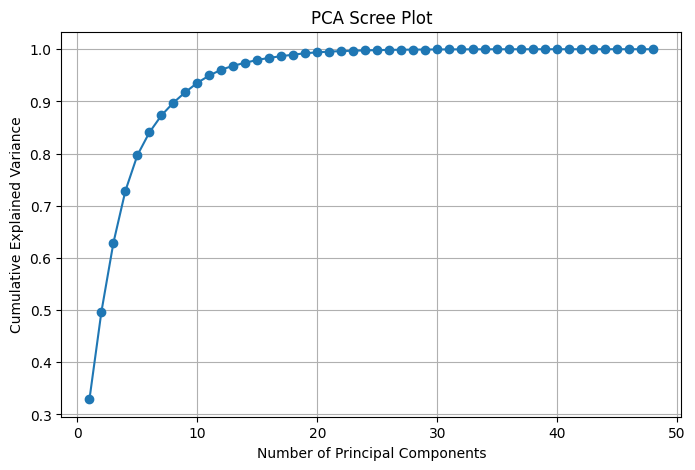

In [26]:
ss = StandardScaler()

#X_train_scaled = ss.fit_transform(X_train)
#X_test_scaled = ss.transform(X_test)

#X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
#X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

pca = PCA()
pca.fit(X_train)
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.title('PCA Scree Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [27]:
num_comp = 20
print(f'Number of Components: {num_comp}')
print(f'Explained Variance: {explained_var[num_comp-1]: .2f}')

Number of Components: 20
Explained Variance:  0.99


In [28]:
pca_final = PCA(n_components=num_comp, random_state=42)

# Apply PCA to all data subsets
X_train_pca = pd.DataFrame(pca_final.fit_transform(X_train_scaled))
X_test_pca = pd.DataFrame(pca_final.transform(X_test_scaled))

In [29]:
#X_train_pca = X_train_pca.drop([0], axis=1)
#X_test_pca = X_test_pca.drop([0], axis=1)

### PCA Baseline

In [30]:
# Function to run a defined model and ouput the results
def run_model(model, X_train, y_train, X_test, y_test, ret_preds=False):
    model.fit(X_train, y_train) # Fit the model

    # Get the predictions for train and test
    train_preds = model.predict(X_train) 
    test_preds = model.predict(X_test)

    # Train and test metrics: r2 and RMSE
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = math.sqrt(mean_squared_error(y_train, train_preds))
    test_r2 = r2_score(y_test, test_preds)
    test_rmse = math.sqrt(mean_squared_error(y_test, test_preds))

    # Adjusted r2 values
    n = X_train.shape[0]; p = X_train.shape[1]
    train_adj_r2 = 1 - (1-train_r2) * (n-1) / (n-p-1)
    n = X_test.shape[0]; p = X_test.shape[1]
    test_adj_r2 = 1 - (1-test_r2) * (n-1)/ (n-p-1)

    # dataframe of metrics
    ret = pd.DataFrame([['Train', train_r2, train_adj_r2, train_rmse], ['Test', test_r2, test_adj_r2, test_rmse]], columns = ['Subset', 'R2', 'Adjusted R2', 'RMSE'])

    # Return metrics and predictions
    if ret_preds == True:
        return train_preds, test_preds, ret
    return ret

In [31]:
# PCA Baseline model (20 components)
run_model(LinearRegression(), X_train_pca, y_train, X_test_pca, y_test)

# Model overfits

,Subset,R2,Adjusted R2,RMSE
0,Train,0.718253,0.686418,7.103601
1,Test,0.581210,0.452351,10.048460


## Lasso

In [32]:
from sklearn.linear_model import Lasso

In [33]:
# Fit and predict with an L1 model
lr = Lasso()
lr.fit(X_train, y_train)
train_preds = lr.predict(X_train)
test_preds = lr.predict(X_test)

pd.DataFrame({
    "Subset": ['Train', 'Test'],
    "R2": [r2_score(y_train, train_preds), r2_score(y_test, test_preds)],
    "RMSE": [math.sqrt(mean_squared_error(y_train, train_preds)), math.sqrt(mean_squared_error(y_test, test_preds))]
})

,Subset,R2,RMSE
0,Train,0.782682,6.238749
1,Test,0.770845,7.433025


In [34]:
print(r2_score(y_train, train_preds))
print(mean_squared_error(y_train, train_preds))

0.7826815939552667
38.9219861871755


In [35]:
print(r2_score(y_test, test_preds))
print(mean_squared_error(y_test, test_preds))

0.7708453183019908
55.24986190006419


In [36]:
# Collect the feature importances from the L1 model
# Store coef and features in a df
l1_coef = pd.DataFrame([X_train.columns, lr.coef_]).transpose()
l1_coef.columns = ['Feature', 'Coef']
l1_coef = l1_coef.sort_values(by='Coef', ascending=False)
l1_coef

,Feature,Coef
20,YY_Post_Neo_Natal_Mortality_Rate_Total,4.736879
43,ZZ_Crude_Death_Rate_Rural_Upper_Limit,3.055951
0,State_Name,2.715434
1,YY_Crude_Death_Rate_Cdr_Total_Female,1.700625
11,VV_Children_Who_Received_Foods_Other_Than_Brea...,0.792683
14,NN_Current_Usage_Emergency_Contraceptive_Pills...,0.587968
23,LL_Crude_Birth_Rate_Cbr_Total,0.0752
34,AA_Currently_Married_Women_Aged_15_49_Years_Total,-0.0
27,ZZ_Crude_Birth_Rate_Total_Upper_Limit,0.0
28,AA_Ever_Married_Women_Aged_15_49_Years_Rural,-0.0


In [37]:
no_coef = list(l1_coef[l1_coef.Coef==0].Feature) # Features with coef of 0
len(no_coef)

38

# Testing Tree Models
- Testing nonlinear models on the full 50 features
- Checking Random Forest feature importances

In [38]:
# Function to graph feature importances from random forest
def rf_feat_imps(feat_imps, feats, top=10):
    rf_imp = pd.DataFrame([feats, feat_imps]).transpose()
    rf_imp.columns = ['Feature', 'Importance']
    rf_imp_sorted = rf_imp.sort_values(by = 'Importance', ascending = False)
    plt.barh(rf_imp_sorted.head(top).Feature, width=rf_imp_sorted.head(10).Importance)
    plt.title(f'Random Forest Top {top} Features')
    plt.xlabel('Feature Importances')
    plt.ylabel('Feature')
    plt.show()

## Decision Tree

In [39]:
dc = DecisionTreeRegressor(max_depth=5)
dc.fit(X_train[imp_feats], y_train)
train_preds = dc.predict(X_train[imp_feats])
test_preds = dc.predict(X_test[imp_feats])

In [40]:
print(r2_score(y_train, train_preds))
print(mean_squared_error(y_train, train_preds))

0.9084550197626065
16.39581534373875


In [41]:
print(r2_score(y_test, test_preds))
print(mean_squared_error(y_test, test_preds))

# Model severely overfits

0.6083345611493506
94.43167927960513


## Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
# Random Forest model of feature importances
rf = RandomForestRegressor(max_depth=5, n_estimators=100)
rf.fit(X_train, y_train.iloc[:, 0])
train_preds = rf.predict(X_train[imp_feats])
test_preds = rf.predict(X_test[imp_feats])

In [44]:
print(r2_score(y_train, train_preds))
print(mean_squared_error(y_train, train_preds))

0.9259853130365172
13.256118872176007


In [45]:
print(r2_score(y_test, test_preds))
print(mean_squared_error(y_test, test_preds))

# model overfits

0.74865707737512
60.59951148143518


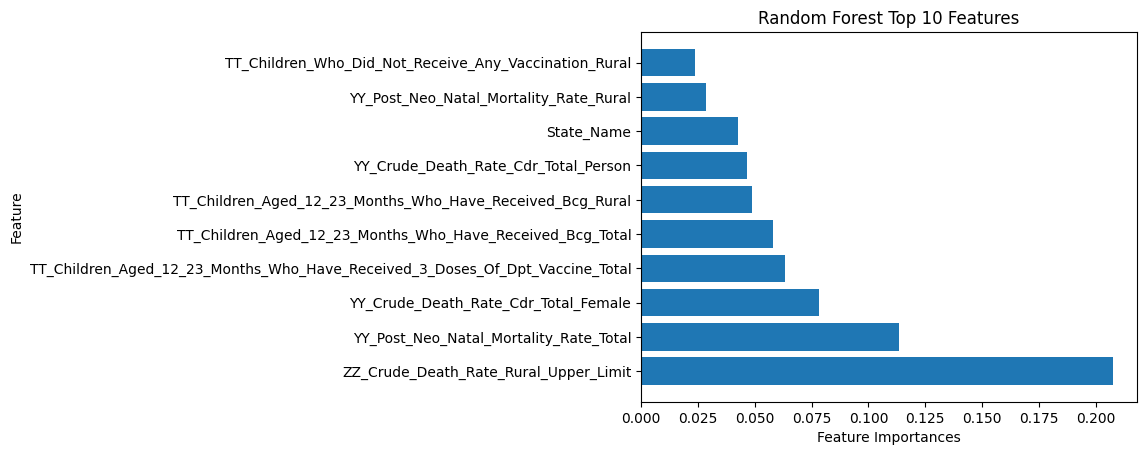

In [46]:
# graph best features from random forest
rf_feat_imps(rf.feature_importances_, X_train[imp_feats].columns) 

# Feature importances make sense, however, the model performs poorly.
# Due to the subpar performance, the RF feature importances are suspect

In [47]:
#imp_coef = rf_imp[rf_imp.Feature.isin(no_coef)].sort_values(by='Importance', ascending=False)

In [48]:
# Made to remove features with <0.01 feature importance
# Not used

#to_remove = list(imp_coef[imp_coef.Importance < 0.01].Feature)
#to_remove

## Boosting

In [49]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost

In [50]:
xg = xgboost.XGBRegressor(max_depth=5, alpha=1.0)

In [51]:
xg.fit(X_train[imp_feats], y_train)
train_preds = xg.predict(X_train[imp_feats])
test_preds = xg.predict(X_test[imp_feats])

In [52]:
# Training metrics
print(r2_score(y_train, train_preds))
print(mean_squared_error(y_train, train_preds))

0.9999170769260991
0.014851621616926018


In [53]:
# Testing metrics
print(r2_score(y_test, test_preds))
print(mean_squared_error(y_test, test_preds))

# Model overfits|

0.7519432973373241
59.80719426696829


# Lasso Feature Filter
- Removing more features using Lasso coefficients
- Preliminary modelling after double feature selection

In [54]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor

In [55]:
# Remove features with a L1 coef of 0
X_train_r = X_train[imp_feats].drop(no_coef, axis=1)
X_test_r = X_test[imp_feats].drop(no_coef, axis=1)

In [56]:
# Remaining features
list(X_train_r.columns)

['State_Name',
 'YY_Crude_Death_Rate_Cdr_Total_Female',
 'AA_Sample_Units_Total',
 'VV_Children_Who_Received_Foods_Other_Than_Breast_Milk_During_First_6_Months_Vegetables_Fruits_Urban',
 'NN_Current_Usage_Emergency_Contraceptive_Pills_Total',
 'YY_Post_Neo_Natal_Mortality_Rate_Total',
 'LL_Crude_Birth_Rate_Cbr_Total',
 'AA_Ever_Married_Women_Aged_15_49_Years_Urban',
 'TT_Children_Aged_12_23_Months_Who_Have_Received_Bcg_Rural',
 'ZZ_Crude_Death_Rate_Rural_Upper_Limit']

In [57]:
# Baseline Linear Regression 
lr = LinearRegression()
run_model(lr, X_train_r, y_train, X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.807076,0.796759,5.878172
1,Test,0.789734,0.761698,7.120097


In [58]:
# L1 Regularization
llr = Lasso()
run_model(llr, X_train_r, y_train, X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.782681,0.771059,6.238762
1,Test,0.770854,0.740301,7.432890


In [59]:
# Ridge Regression
rlr = Ridge()
run_model(rlr, X_train_r, y_train, X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.807046,0.796727,5.878633
1,Test,0.789567,0.761509,7.122926


In [60]:
# Decision Tree Update
run_model(dc, X_train_r, y_train, X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.896582,0.891052,4.303755
1,Test,0.631636,0.582521,9.424094


In [61]:
# Random Forest Update
rf = RandomForestRegressor(max_depth=5, n_estimators=100)
run_model(rf, X_train_r, y_train.iloc[:, 0], X_test_r, y_test.iloc[:, 0])

,Subset,R2,Adjusted R2,RMSE
0,Train,0.915684,0.911175,3.886010
1,Test,0.776814,0.747056,7.335585


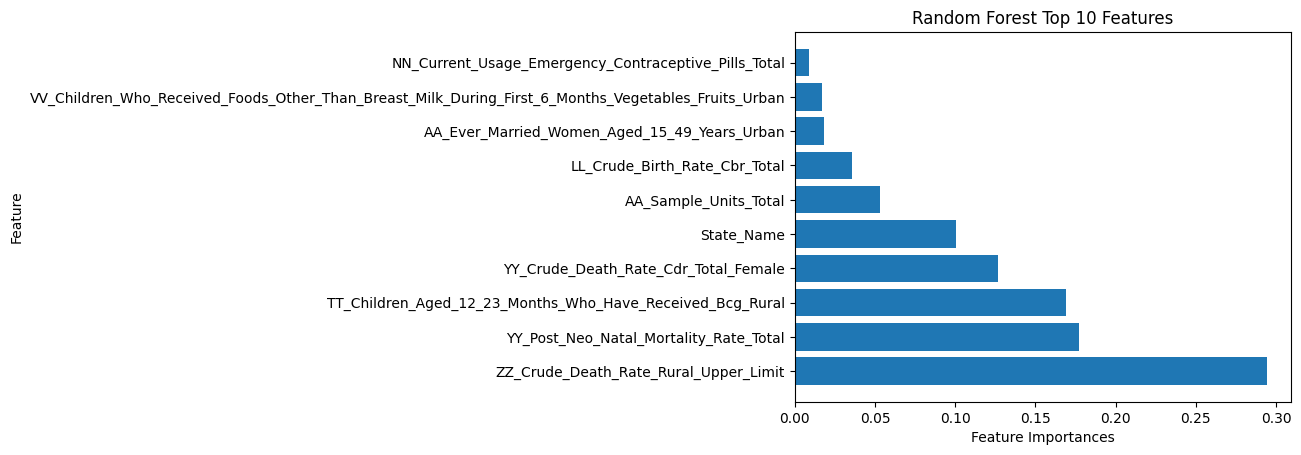

In [62]:
rf_feat_imps(rf.feature_importances_, X_train_r.columns)

In [63]:
# XGBoost Update
run_model(xg, X_train_r, y_train, X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.999864,0.999857,0.155958
1,Test,0.756851,0.724431,7.656627


In [64]:
# Adaptive Boosting with an L2 (Ridge) Regression base model
ada = AdaBoostRegressor(estimator=Ridge(), n_estimators=100, learning_rate=1.0, random_state=42)
run_model(ada, X_train_r, y_train.iloc[:, 0], X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.802148,0.791567,5.952778
1,Test,0.789817,0.761793,7.118690


In [65]:
# KNN Model
knn = KNeighborsRegressor(n_neighbors = 5)
run_model(knn, X_train_r, y_train, X_test_r, y_test)

,Subset,R2,Adjusted R2,RMSE
0,Train,0.802650,0.792097,5.945217
1,Test,0.711628,0.673179,8.338302


#### Preliminary Modelling Conclusion
- Baseline model is far better
- Nonlinear models overfit, even at low complexity
- Linear models perform well, but can be improved
- Ridge Regression and Adaptive Boosting seem to have the most potential

# Residuals
- Baseline model residuals after double feature selection

In [66]:
# New baseline model
lr = LinearRegression()
train_preds,test_preds,lr_metrics=run_model(lr, X_train_r, y_train, X_test_r, y_test, ret_preds=True)

In [67]:
# Baseline residuals
train_residuals = y_train-train_preds
test_residuals = y_test-test_preds

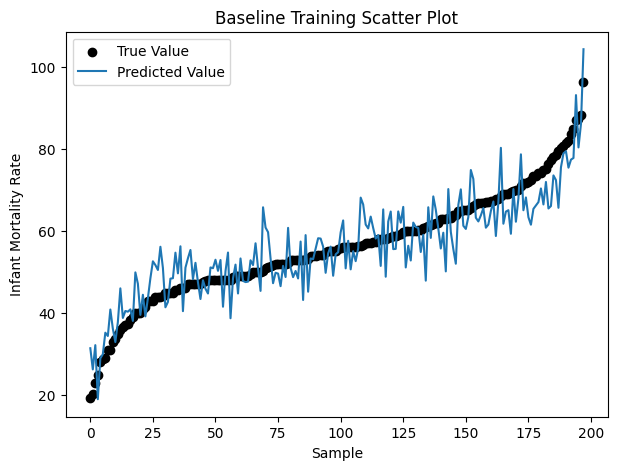

In [68]:
# Graph predictions vs true values
train_sorted_index = y_train.reset_index(drop=True).sort_values(by='YY_Infant_Mortality_Rate_Imr_Total_Person').index
ordered_preds_train = pd.DataFrame(train_preds).reindex(train_sorted_index).loc[:][0]

plt.figure(figsize=(7,5))
plt.scatter(np.arange(len(X_train_scaled)),sorted(y_train.YY_Infant_Mortality_Rate_Imr_Total_Person), color='black', label='True Value')
plt.title('Baseline Training Scatter Plot')
plt.plot(np.arange(len(X_train_scaled)),ordered_preds_train, label = 'Predicted Value')
plt.ylabel('Infant Mortality Rate')
plt.xlabel('Sample')
plt.legend()
plt.show()

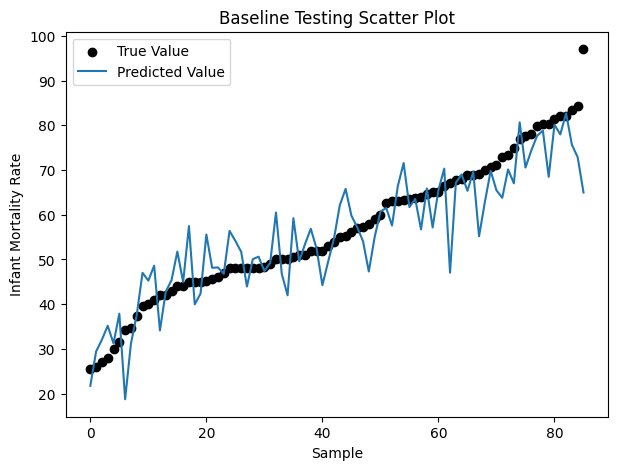

In [69]:
# Baseline Test Scatter Plot
test_sorted_index = y_test.reset_index(drop=True).sort_values(by='YY_Infant_Mortality_Rate_Imr_Total_Person').index
ordered_preds_test = pd.DataFrame(test_preds).reindex(test_sorted_index).loc[:][0]

plt.figure(figsize=(7,5))
plt.scatter(np.arange(len(X_test_scaled)),sorted(y_test.YY_Infant_Mortality_Rate_Imr_Total_Person), color='black', label='True Value')
plt.title('Baseline Testing Scatter Plot')
plt.plot(np.arange(len(X_test_scaled)),ordered_preds_test, label = 'Predicted Value')
plt.ylabel('Infant Mortality Rate')
plt.xlabel('Sample')
plt.legend()
plt.show()

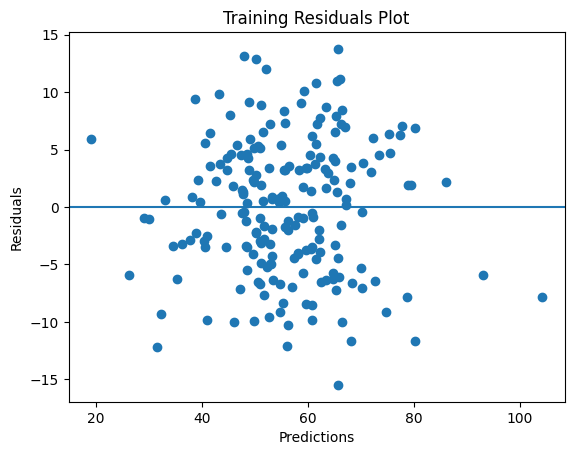

In [70]:
# Training Residuals plot
plt.scatter(y=train_residuals, x=train_preds)
plt.axhline(y=0)
plt.title("Training Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

# Mostly randomly scattered around 0
# Wide range of residuals

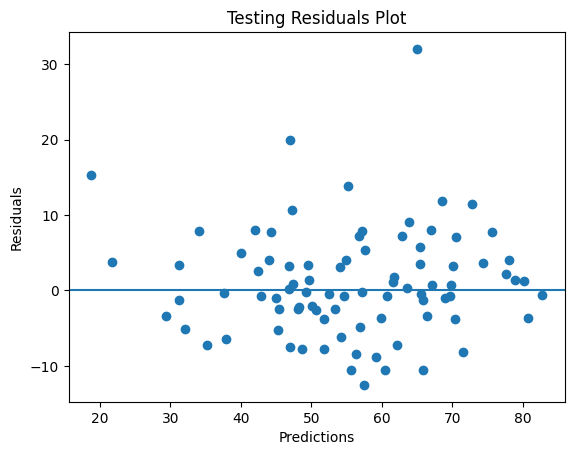

In [71]:
plt.scatter(y=test_residuals, x=test_preds)
plt.axhline(y=0)
plt.title("Testing Residuals Plot")
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.show()

# Notable residual outlier ~30

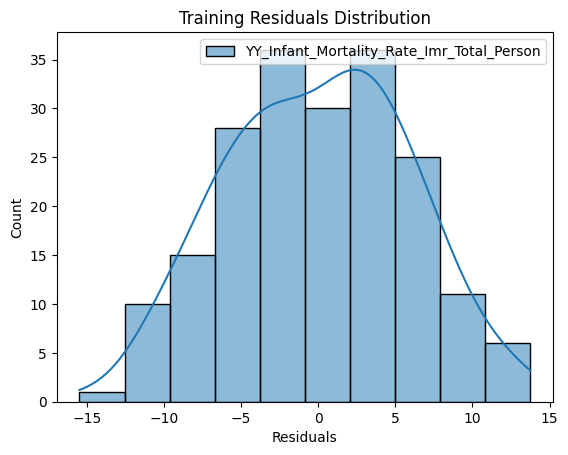

In [72]:
# Residuals Distribution
sns.histplot(train_residuals, kde=True)
plt.title('Training Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

# Normally Distributed

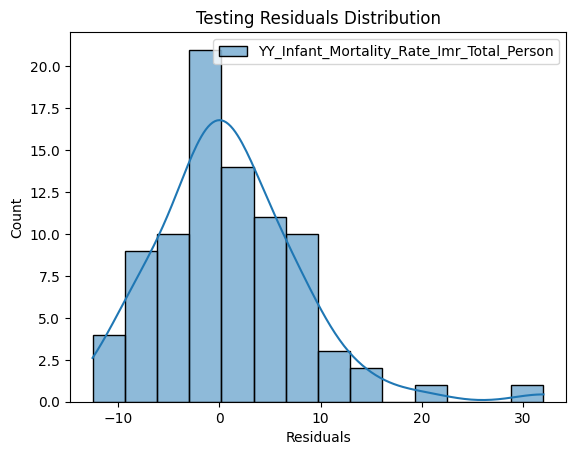

In [73]:
sns.histplot(test_residuals, kde=True)
plt.title('Testing Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.show()

# Heavy right skew
# Potential outlier problem

## Problematic Cases
- Exploring outliers among the resiudals

In [74]:
# Collect and store predicted values and resiudals from testing set
special_cases = y_test.copy(deep=True)
special_cases['Predicted'] = test_preds
special_cases['Residuals'] = test_residuals

In [75]:
# Get state and district names to identify outlier cases
state_dist = df_all[['State_Name', 'State_District_Name']]
special_cases = pd.concat([state_dist, special_cases], axis=1, join='inner')

In [76]:
# Standardize the residuals
# Allows for identifying outliers based on the standard normal distribution
z_scaler = StandardScaler()
special_cases['Standard_Residuals'] = z_scaler.fit_transform(special_cases[['Residuals']])

In [77]:
# Find outler cases where abs residucals z-score > 1.9
outlier_cases = special_cases[np.abs(special_cases['Standard_Residuals'])>=1.9]
outlier_cases.rename(columns={target: 'y_true'})

# Cases can be identified in external EDA (Tableau)

,State_Name,State_District_Name,y_true,Predicted,Residuals,Standard_Residuals
140,Odisha,Balangir,97.00,64.961188,32.038812,4.404699
157,Odisha,Khordha,67.00,47.044663,19.955337,2.691690
232,Uttar Pradesh,Hamirpur,44.94,57.468970,-12.528970,-1.913435
275,Uttarakhand,Dehradun,34.14,18.769337,15.370663,2.041745


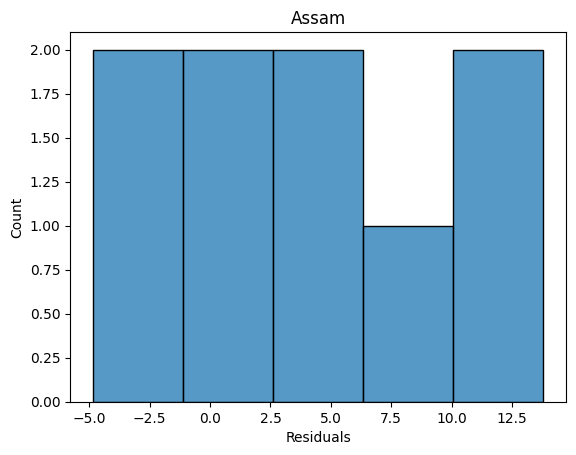

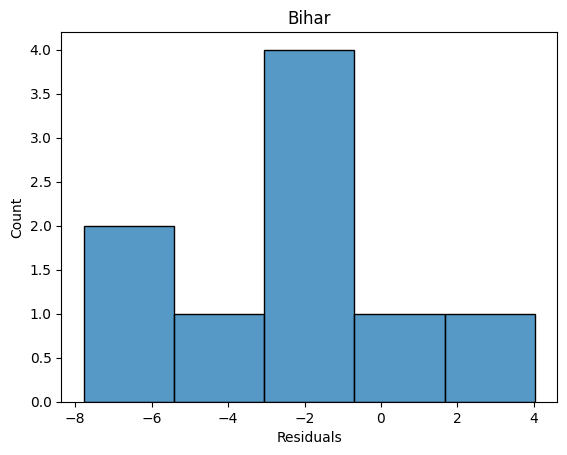

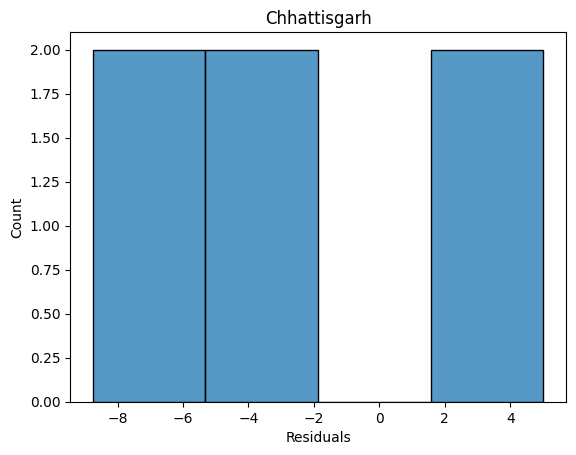

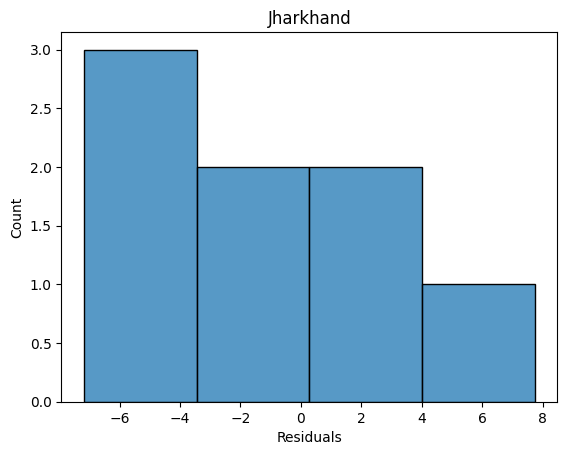

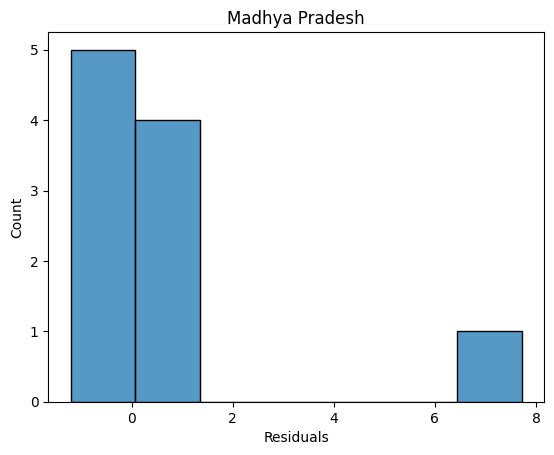

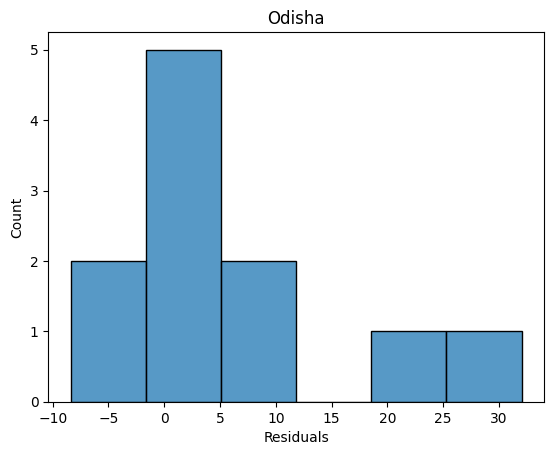

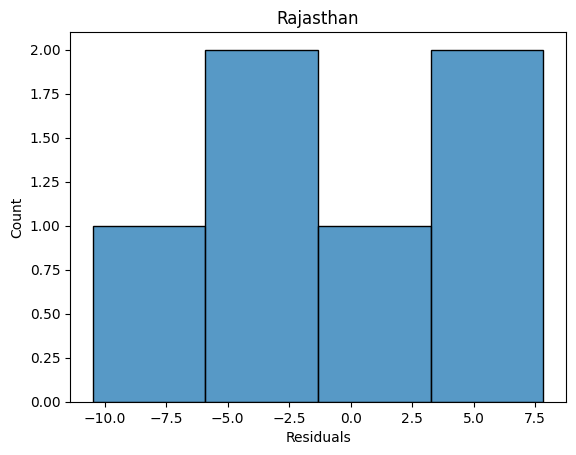

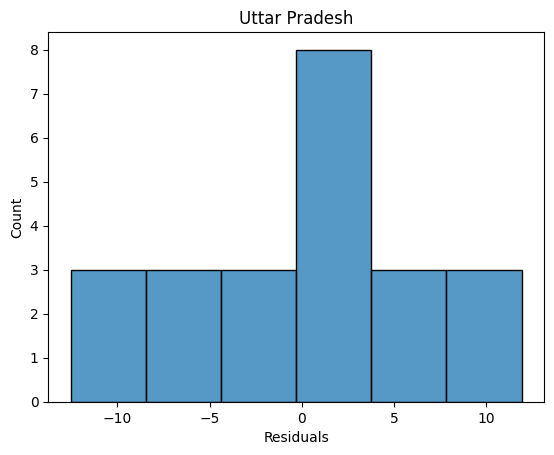

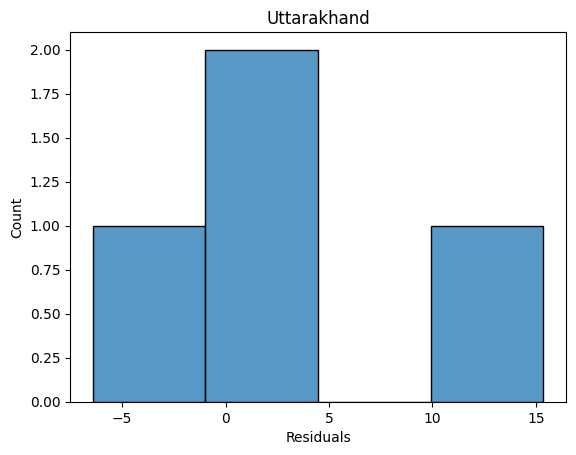

In [78]:
# Distribute residuals by state
for state in special_cases.State_Name.unique():
    sns.histplot(special_cases[special_cases['State_Name']==state].Residuals)
    plt.title(state)
    plt.show()

# Odisha has a wide range of residuals and contains the most notable outlier (Balangir)

In [79]:
# Create a shap model for the baseline
# Allows for exploring feature impacts on baseline model predictions
explainer = shap.LinearExplainer(lr, X_train_r)
shap_values = explainer(X_train_r)

Text(0.43, 0.95, ' Baseline Linear Regression Shap Plot')

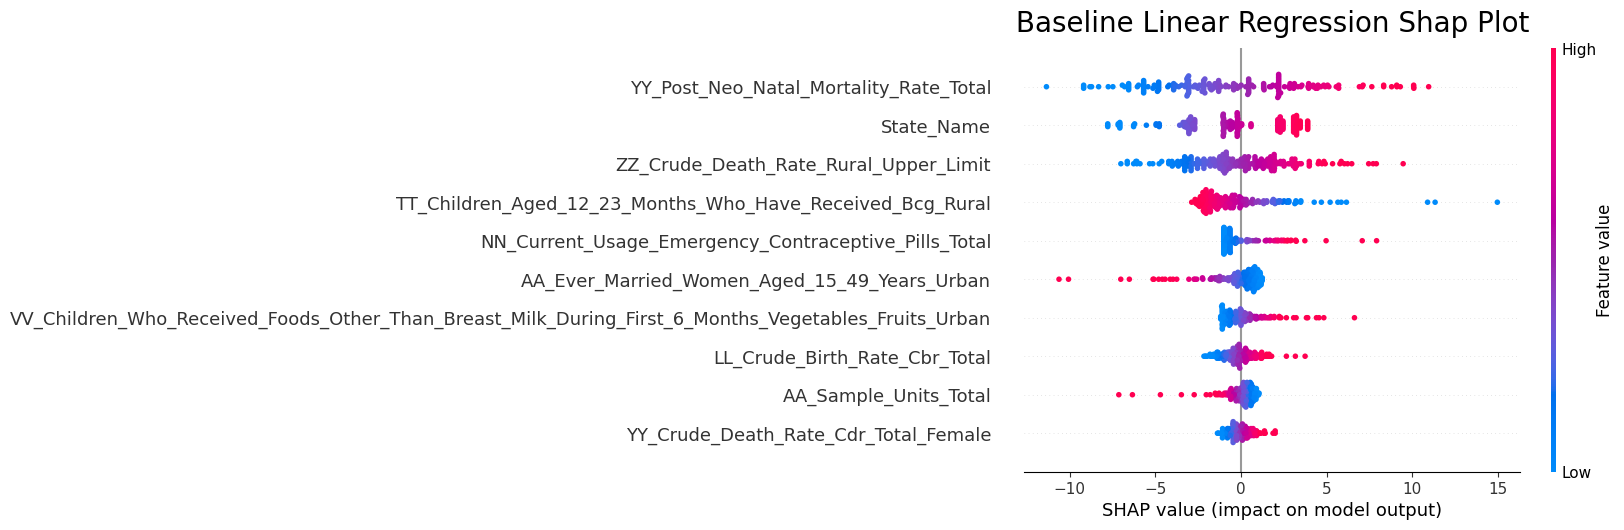

In [80]:
# Create a shap beeswarm plot
# Global explainability plot that shows general feature impacts on predictions
shap.plots.beeswarm(shap_values, max_display = len(shap_values[1]), show=False)
plt.suptitle(" Baseline Linear Regression Shap Plot", y=0.95, x=0.43, fontsize=20)
#plt.savefig('baseline_shap_plot.png', bbox_inches='tight')

# Neo_Natal, State, and Death_Rate have the greatest impact
# Features all have general linear trends

## Export Important Features

In [81]:
imp_feats.append(target) # Include the target variable
imp_feats.append('State_District_Name') # Include the district names
df_imp = df_all[imp_feats]
df_imp.head()

,State_Name,YY_Crude_Death_Rate_Cdr_Total_Female,AA_Sample_Units_Total,YY_Crude_Death_Rate_Cdr_Rural_Person,AA_Sample_Units_Rural,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Rural_Male,AA_Sample_Units_Urban,TT_Children_Aged_12_23_Months_Who_Have_Received_Measles_Vaccine_Rural,YY_Crude_Death_Rate_Cdr_Rural_Female,...,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Total,ZZ_Crude_Death_Rate_Rural_Lower_Limit,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Polio_Vaccine_Rural,ZZ_Crude_Death_Rate_Rural_Upper_Limit,EE_Marriages_Among_Males_Below_Legal_Age_21_Years_Total,YY_Crude_Death_Rate_Cdr_Total_Person,TT_Children_Aged_12_23_Months_Who_Have_Received_3_Doses_Of_Dpt_Vaccine_Total,YY_Crude_Death_Rate_Cdr_Total_Male,YY_Infant_Mortality_Rate_Imr_Total_Person,State_District_Name
0,Assam,5.1,53,6.7,47,76.3,8.1,6,76.7,5.3,...,76.5,5.9,76.6,7.5,8.8,6.6,78.5,8.1,43.0,Barpeta
1,Assam,4.4,89,6.3,73,79.4,8.0,16,79.0,4.5,...,67.8,5.7,67.5,6.9,9.9,6.1,66.6,7.8,48.0,Bongaigaon
2,Assam,6.3,105,7.4,84,80.3,8.3,21,80.3,6.5,...,71.3,6.9,70.6,8.0,4.1,7.3,77.1,8.2,53.0,Cachar
3,Assam,7.7,26,8.1,24,71.6,8.5,2,71.1,7.8,...,79.3,6.9,79.5,9.3,11.1,8.1,70.8,8.4,70.0,Darrang
4,Assam,3.7,121,4.5,108,77.5,5.3,13,77.0,3.7,...,80.4,4.1,79.9,4.9,9.5,4.5,78.0,5.3,37.0,Dhemaji


In [82]:
#df_imp.to_csv('df_imp.csv', index=False)